In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Cargamos el dataset
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/company.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente

Mounted at /content/drive
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
# Realizamos un breve ánalisis exploratorio
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


<Axes: >

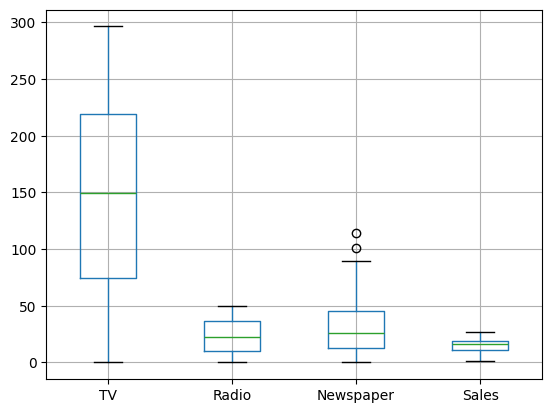

In [5]:
df.boxplot()

El dataset presenta cuatro variables: TV, Radio, Newspaper y Sales. No contiene valores nulos y todas las variables son floats. TV muestra una mayor variabilidad y escala en comparación con las otras. En general, las variables no parecen presentar una cantidad significativa de outliers.

<Axes: >

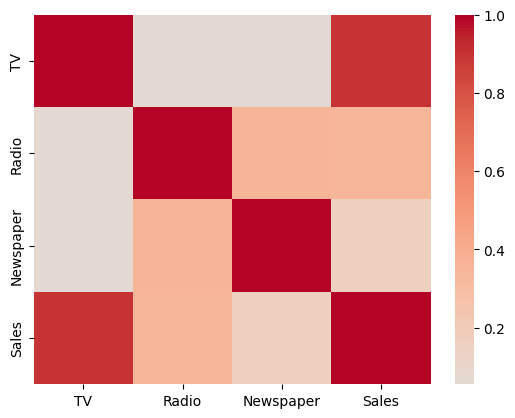

In [6]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)

Se muestran diversas correlaciones de intensidad moderada-baja. Ventas y TV presentan una correlación positiva.

In [7]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Dividimos el data set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

# Normalizamos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
# Ridge
alphas = np.logspace(-10, 2, 200)


ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

y_pred_ridge = ridge_cv.predict(X_test)
mse_ridge_test = mean_squared_error(y_test, y_pred_ridge)
r2_ridge_test = r2_score(y_test, y_pred_ridge)

In [9]:
# Lasso
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

y_pred_lasso = lasso_cv.predict(X_test)
mse_lasso_test = mean_squared_error(y_test, y_pred_lasso)
r2_lasso_test = r2_score(y_test, y_pred_lasso)

In [10]:
# Comparamos los resultados
print("--- RESULTADOS RIDGE ---")
print(f"Mejor alpha: {ridge_cv.alpha_}")
print(f"MSE test: {mse_ridge_test:.4f} | R² test: {r2_ridge_test:.4f}")
print(f"Coef: {ridge_cv.coef_}")

print("\n--- RESULTADOS LASSO ---")
print(f"Mejor alpha: {lasso_cv.alpha_}")
print(f"MSE test: {mse_lasso_test:.4f} | R² test: {r2_lasso_test:.4f}")
print(f"Coef: {lasso_cv.coef_}")

--- RESULTADOS RIDGE ---
Mejor alpha: 1.7834308769319056
MSE test: 2.1618 | R² test: 0.9171
Coef: [ 4.63289081  1.6818536  -0.0138008 ]

--- RESULTADOS LASSO ---
Mejor alpha: 0.02768286630392061
MSE test: 2.1404 | R² test: 0.9179
Coef: [ 4.65635701  1.66797394 -0.        ]


En el caso de Lasso, como era de esperar, el coeficiente de la variable Newspaper es 0, mientras que en Ridge también se mantiene muy bajo. Ambos modelos muestran un rendimiento muy similar, aunque el mejor alpha de Lasso es más pequeño (0.02) frente a Ridge (1.7). Ambos alcanzan un nivel de significación alrededor de 0.91.

A medida que aumentamos α, los coeficientes tienden a acercarse a 0, en el caso de Lasso, algunas variables incluso llegan a desaparecer por completo.

Ridge es más “flexible”, ya que no tiende a eliminar variables, mientras que Lasso sí puede dejar fuera aquellas que no aportan mucho al modelo.

En cuanto al rendimiento, ambos son muy similares, pero siguiendo la ley de parsimonia, Lasso puede ser preferible porque genera modelos más simples.

La regularización ayuda a que las variables menos importantes tengan menos peso. Además, en situaciones de multicolinealidad o riesgo de sobreajuste, mantiene los coeficientes más estables, evitando que se disparen demasiado con los datos de entrenamiento o con una fuerte correlación.

En datasets con muchas variables o con varias irrelevantes, Lasso suele ser preferible porque tiende a eliminar las que no aportan al modelo. En cambio, si el conjunto de datos es pequeño o se desea conservar todas las variables, Ridge resulta más conveniente.

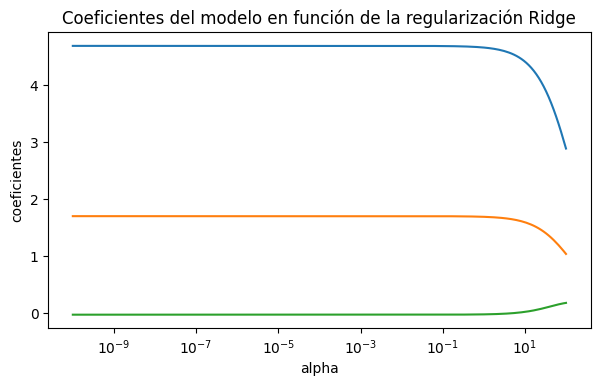

In [11]:
alphas = ridge_cv.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización Ridge');
plt.axis('tight')
plt.show()

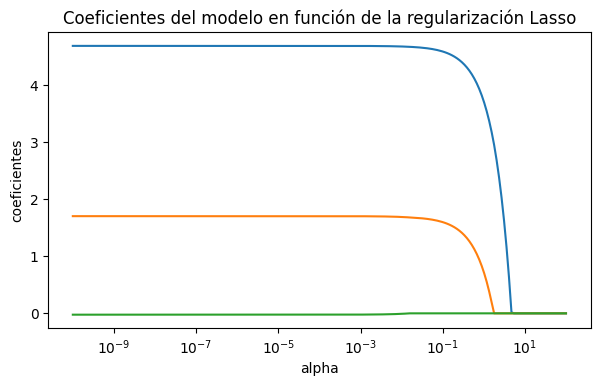

In [12]:
alphas = lasso_cv.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización Lasso');
plt.axis('tight')
plt.show()

Se observa que el valor de los coeficientes no varía demasiado en ambos modelos y a partir de qué valores Lasso drásticamente los pone a 0.